#### 1.Importing the Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#### 2.Importing the Dataset

In [2]:
df = pd.read_csv(
    "D:\\Desktop\\OIBSIP\\Task 1 EDA Retail\\retail_sales_dataset.csv")

In [ ]:
df.head()

In [3]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


#### 3.Describing the Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


In [10]:
df.shape

(1000, 9)

**Checking the data that is there any null values are there or not**

In [11]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

**As you can see there is no null values. It's good to go**

#### 4.Visualize the Dataset

In [12]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


**Unique values of the dataset**

In [13]:
df.nunique()

Transaction ID      1000
Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
dtype: int64

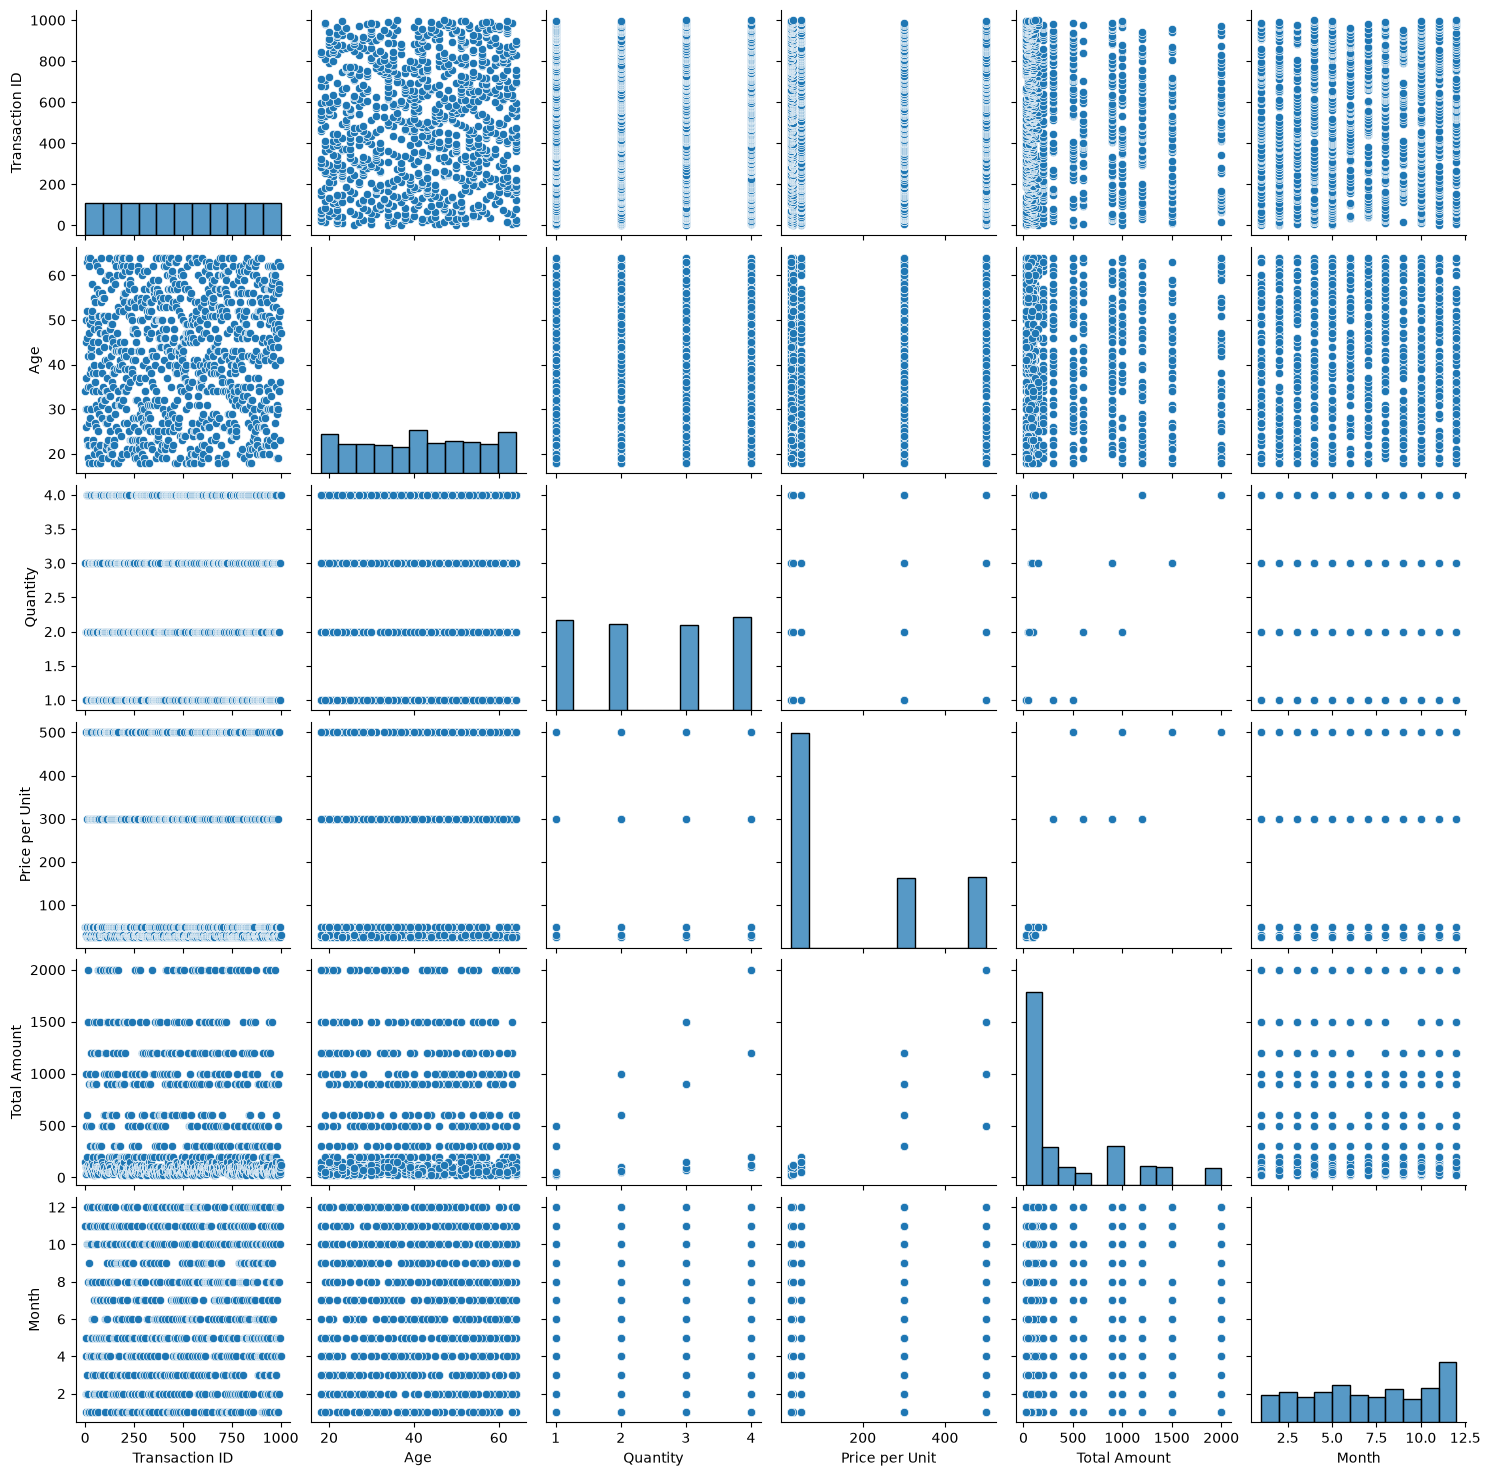

In [42]:
sns.pairplot(df)
plt.show()

**Counting the Products in Product Category**

In [17]:
df[df['Product Category'].isin(['Clothing','Beauty','Electronics'])]['Product Category'].value_counts()

Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

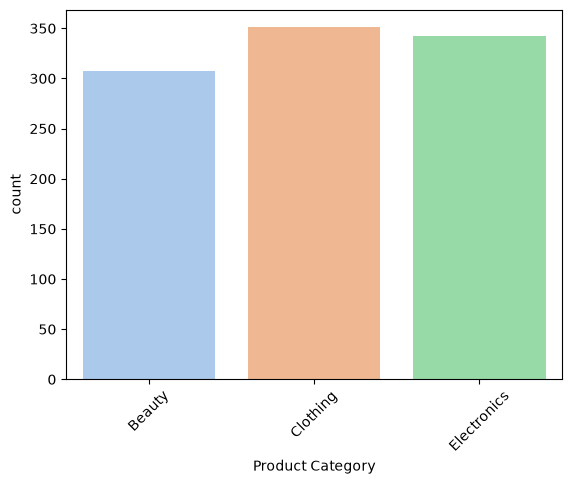

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example count plot with a color palette
sns.countplot(x=df['Product Category'],palette='pastel')

plt.xticks(rotation=45) # Rotate X labels if needed
plt.show()

**Group data by 'Product Category' and summarize it by quantity and total amount**

In [20]:
df.groupby('Product Category')[['Quantity','Total Amount']].sum()

,Quantity,Total Amount
Product Category,,
Beauty,771,143515
Clothing,894,155580
Electronics,849,156905


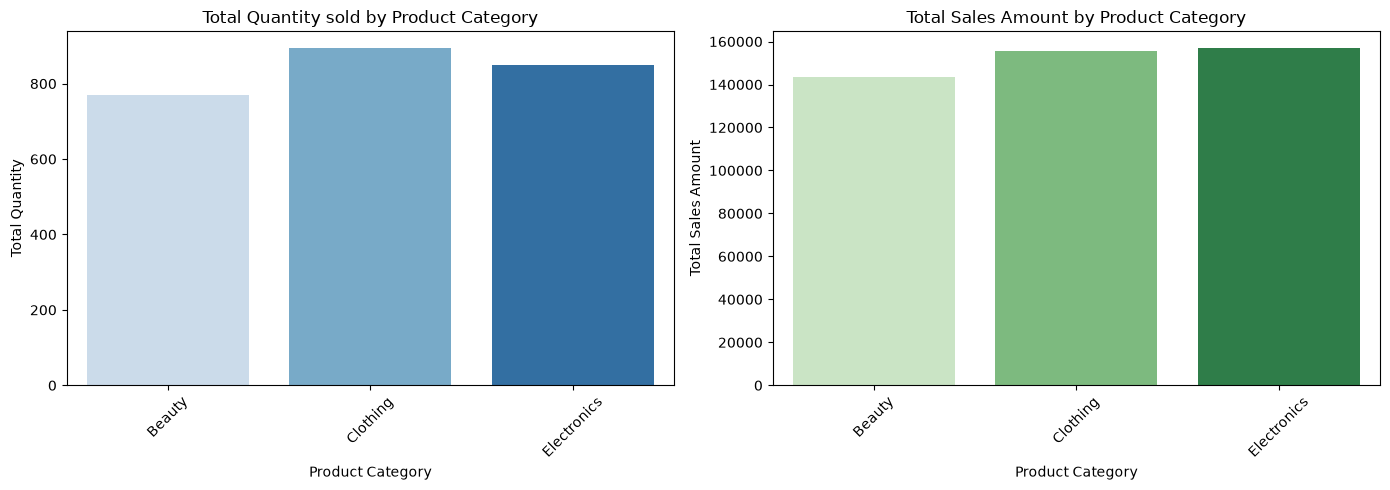

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grouping data
category_summary = df.groupby('Product Category')[['Quantity','Total Amount']].sum()

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot for Quantity
sns.barplot(x=category_summary.index, y=category_summary['Quantity'],ax=ax[0], palette='Blues')
ax[0].set_title('Total Quantity sold by Product Category')
ax[0].set_xlabel('Product Category')
ax[0].set_ylabel('Total Quantity')
ax[0].tick_params(axis='x', rotation=45)

# Bar plot for Total Amount
sns.barplot(x=category_summary.index, y=category_summary['Total Amount'],ax=ax[1], palette='Greens')
ax[1].set_title('Total Sales Amount by Product Category')
ax[1].set_xlabel('Product Category')
ax[1].set_ylabel('Total Sales Amount')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


**Create a Pie Chart for showing the Percentage for each Product Category**

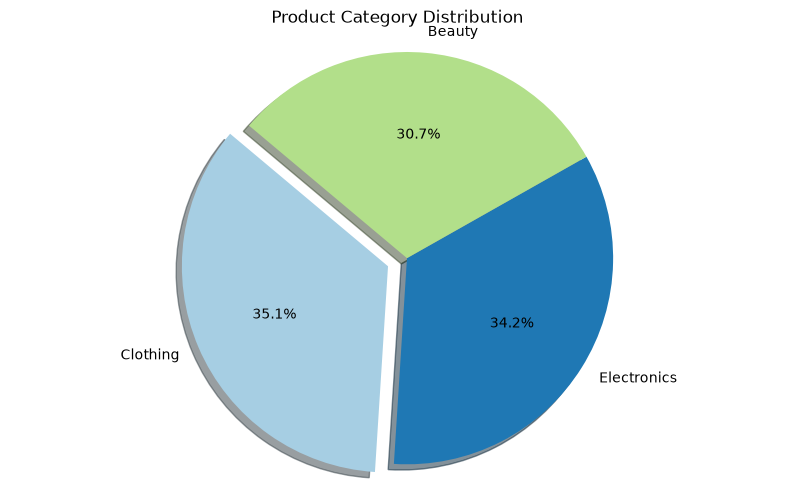

In [27]:
# Count the occurences of each product category
category_counts = df['Product Category'].value_counts()

# Define explodeto highlight the largest category
explode_list = [0.1 if i == category_counts.idxmax() else 0 for i in category_counts.index]

# Plot pie chart
plt.figure(figsize=(10,6))
plt.pie(
    category_counts,
    labels = category_counts.index,
    autopct = '%1.1f%%', # Display percentage values
    colors = plt.cm.Paired.colors, # Different colors for categories
    explode = explode_list, # Highlighting the highest values
    startangle = 140,
    shadow = True
)

plt.title('Product Category Distribution')
plt.axis("equal") # Ensures the pie chart is circular
plt.show()

**Split the Dates into day, month and year**

In [29]:
# Seeing the date column
df['Date'] = pd.to_datetime(df['Date'])

# Add 'month' column and extract month from date
df['Month'] = df['Date'].dt.month_name()
df['Month']

0      November
1      February
2       January
3           May
4           May
         ...   
995         May
996    November
997     October
998    December
999       April
Name: Month, Length: 1000, dtype: str

**Total Sales Amount over each month**

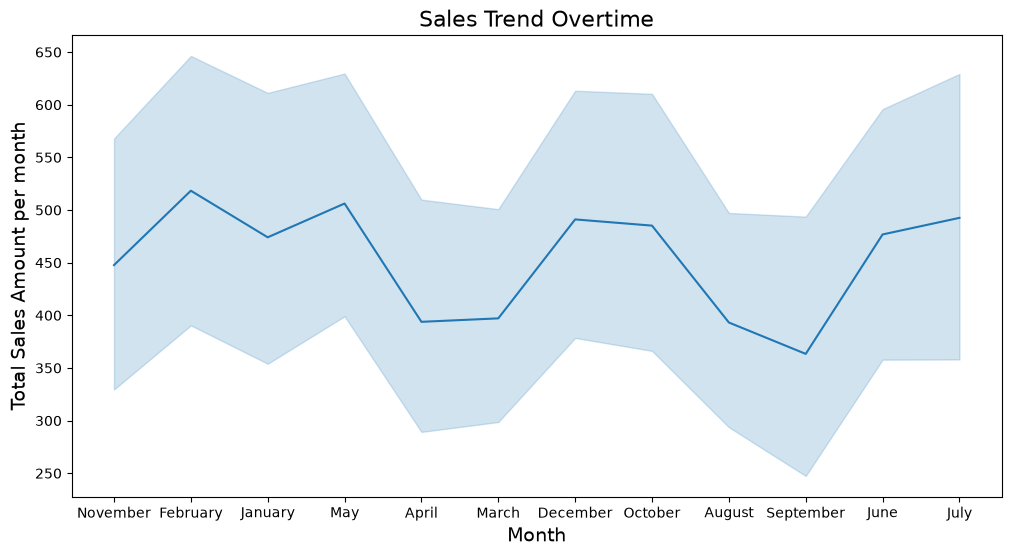

In [30]:
# Sales trends Overtme
plt.figure(figsize = (12,6))
sns.lineplot(x = 'Month', y = 'Total Amount', data = df)
plt.title('Sales Trend Overtime', fontsize = 16)
plt.xlabel('Month',fontsize = 14)
plt.ylabel('Total Sales Amount per month', fontsize = 14)
plt.show()

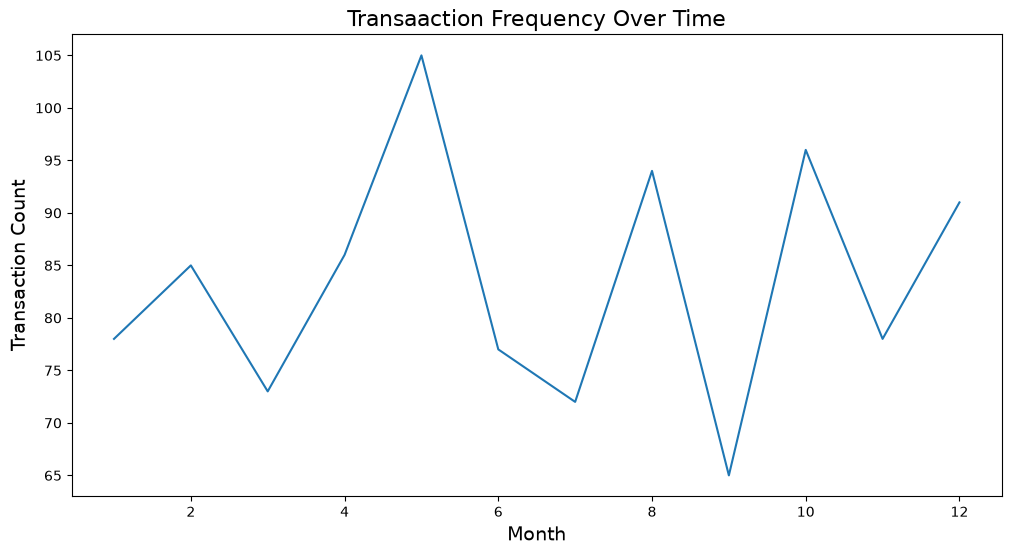

In [32]:
df['Month'] = df['Date'].dt.month
transaction_count = df.groupby('Month')['Transaction ID'].count()

plt.figure(figsize = (12,6))
sns.lineplot(x = transaction_count.index, y = transaction_count.values)
plt.title('Transaaction Frequency Over Time', fontsize = 16)
plt.xlabel('Month',fontsize = 14)
plt.ylabel('Transaction Count', fontsize = 14)
plt.show()

**Transaction frequency over each month**

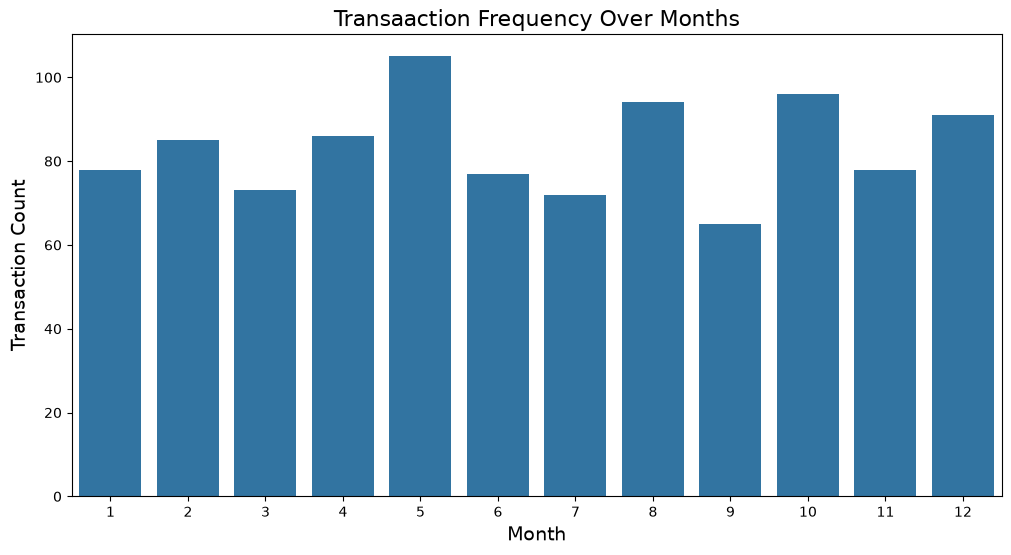

In [33]:
plt.figure(figsize = (12,6))
sns.barplot(x = transaction_count.index, y = transaction_count.values)
plt.title('Transaaction Frequency Over Months', fontsize = 16)
plt.xlabel('Month',fontsize = 14)
plt.ylabel('Transaction Count', fontsize = 14)
plt.show()

**Sales Heatmap**

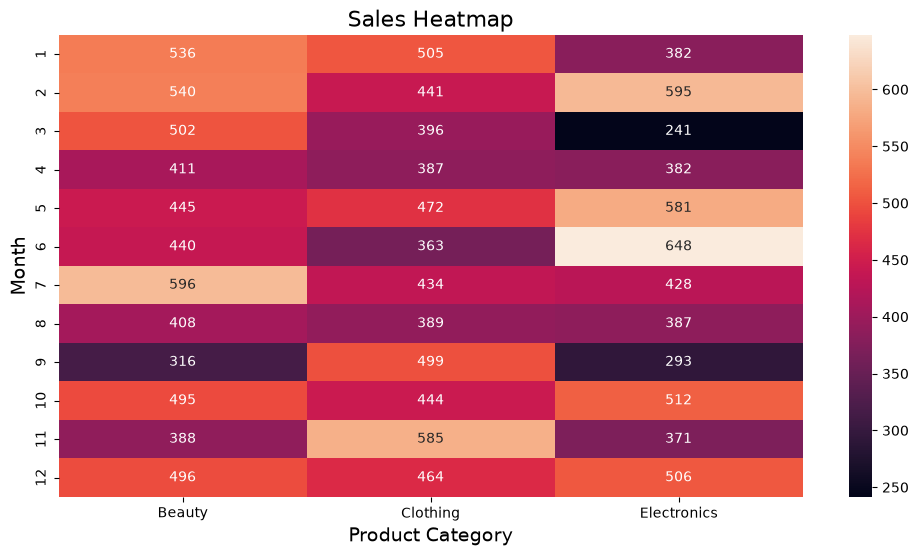

In [34]:
heatmap = df.pivot_table(index = 'Month', columns = 'Product Category', values = 'Total Amount')
plt.figure(figsize = (12,6))
sns.heatmap(heatmap, annot=True, fmt='.0f')
plt.title('Sales Heatmap', fontsize = 16)
plt.xlabel('Product Category',fontsize = 14)
plt.ylabel('Month', fontsize = 14)
plt.show()

**Gender for Male and Female**

In [35]:
df['Age'].count()

np.int64(1000)

In [37]:
df[df['Gender'].isin(['Male', 'Female'])]['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

**Pie Chart**

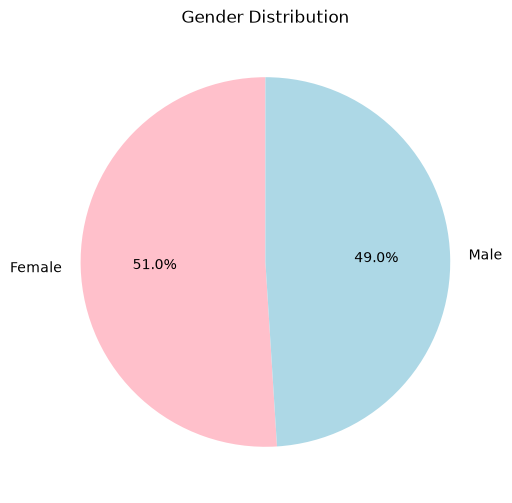

In [38]:
gender_counts = {'Female': 510, 'Male': 490}

#plot
plt.figure(figsize = (6,6))
plt.pie(gender_counts.values(), labels=gender_counts.keys(), autopct= '%1.1f%%', colors = ['pink', 'lightblue'], startangle = 90)
plt.title('Gender Distribution')
plt.show()

**Bining the Age**

In [39]:
age_bins = [0, 18, 25, 35, 50, 100]
age_group = ['0-18', '19-25', '26-35', '36-50', '50+']
df['Age Group'] = pd.cut(df['Age'], bins = age_bins, labels = age_group)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11,26-35
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2,26-35
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1,36-50
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5,36-50
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5,26-35


**Distribution of the Age and Gender column in Product Category**

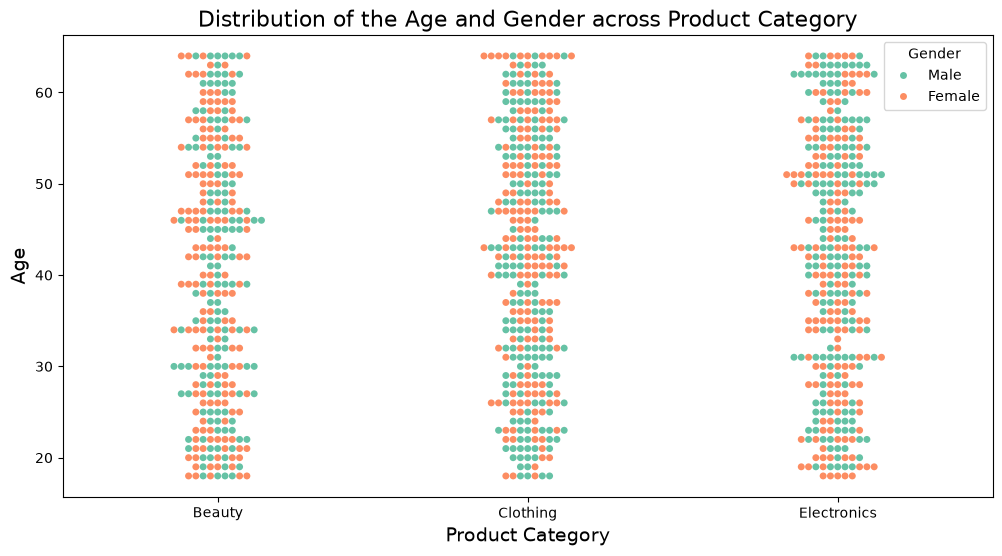

In [40]:
plt.figure(figsize = (12,6))
sns.swarmplot(x = 'Product Category', y = 'Age', hue='Gender', data = df, palette = 'Set2')
plt.title('Distribution of the Age and Gender across Product Category', fontsize = 16)
plt.xlabel('Product Category',fontsize = 14)
plt.ylabel('Age', fontsize = 14)
plt.legend( title = 'Gender', loc = 'upper right', fontsize = 10)
plt.show()

**Histogram for count of Age Persons**

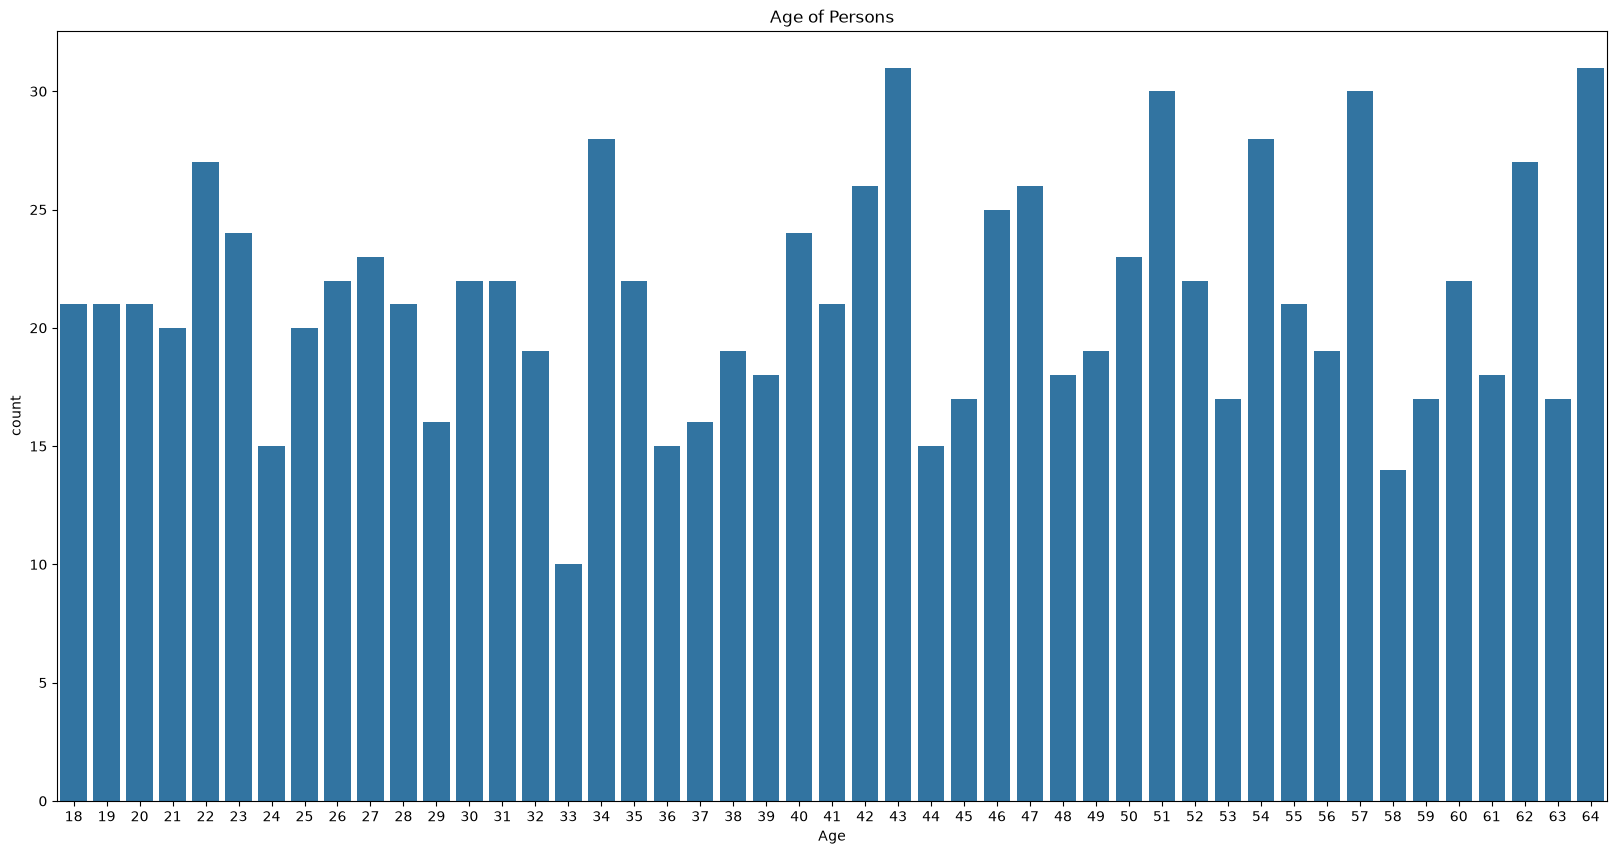

In [5]:
plt.figure(figsize = (20,10))
plt.title('Age of Persons')
plt.xlabel('Age')
sns.countplot( x = 'Age', data = df)
plt.show()

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Month             1000 non-null   int32         
 10  Age Group         1000 non-null   category      
dtypes: category(1), datetime64[us](1), int32(1), int64(5), str(3)
memory usage: 75.4 KB


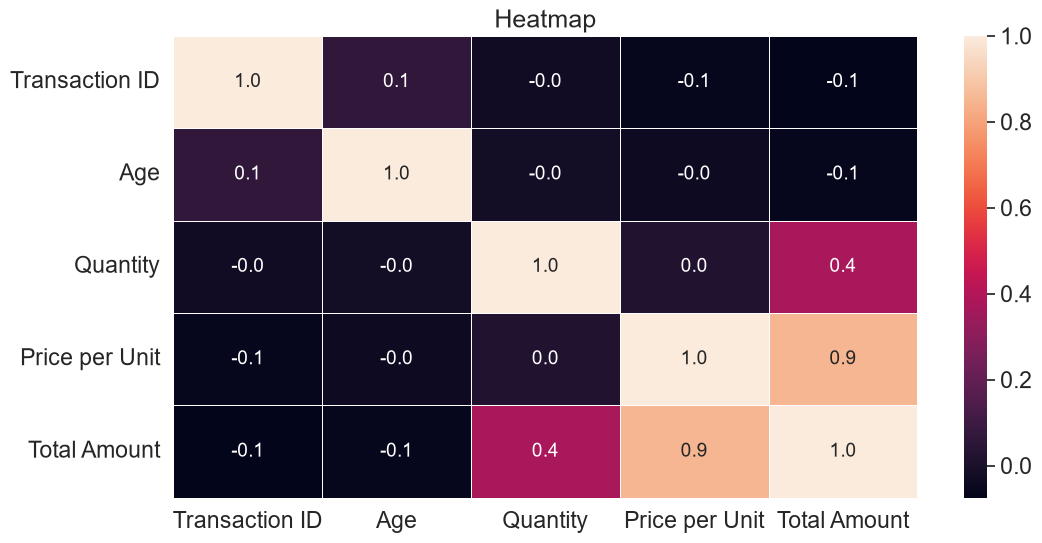

In [45]:
correlation = df[df.dtypes[df.dtypes == 'int64'].index].corr()
sns.set(font_scale = 1.5)
plt.figure(figsize = (12,6))
plt.title('Heatmap', fontsize = 18)
ax = sns.heatmap(correlation, annot = True, annot_kws = {"size": 14},fmt = '.1f', linewidths = .5)